# Libraries

In [1]:
from functions import *
from UQpy.distributions import Normal, JointIndependent
# Do you want plot with latex font format? Use the cell bellow:
import matplotlib as mpl
mpl.rcParams.update({
                        'font.family': 'serif',
                        'mathtext.fontset': 'cm',
                        'axes.unicode_minus': False
                    })
import seaborn as sns
import numpy as np

d:\Documentos\ic_victor\myenv\Lib\site-packages\UQpy\__init__.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


# Dataset

### General data

In [2]:
n_latent_samples = 2000
n_samples = 1000
r = Normal(loc = 5.09, scale=0.8)
s = Normal(loc = 1.80, scale=0.6) 

### State limit function $t$ = 0

In [3]:
step_time_0 = 0.0
divs = 10

In [ ]:
joint = JointIndependent(marginals=[r, s])
x_val = joint.rvs(n_samples)
submatrices = np.array_split(x_val, divs)
df_0, glam_data_0 = g_toy_problem_parallel_with_multiprocessing(submatrices, n_latent_samples, t=step_time_0)
glam_data_0

### State limit function $t$ = 50

In [6]:
step_time_50 = 100.0
divs = 10

In [7]:
joint = JointIndependent(marginals=[r, s])
x_val = joint.rvs(n_samples)
submatrices = np.array_split(x_val, divs)
df_50, glam_data_50 = g_toy_problem_parallel_with_multiprocessing(submatrices, n_latent_samples, t=step_time_50)
glam_data_50

,r,s,lambda 1,lambda 2,lambda 3,lambda 4
0,4.119851,1.773889,-0.528681,8.389171,0.090233,0.187546
1,4.788696,1.085788,0.357639,13.765604,0.078279,0.151771
2,3.960745,1.180521,0.017317,12.363280,0.109084,0.184467
3,4.030134,1.916194,-0.701648,7.700350,0.119598,0.208535
4,4.294431,2.208897,-0.905851,7.242521,0.078119,0.182899
...,...,...,...,...,...,...
995,4.123126,2.056435,-0.807054,7.639816,0.049522,0.178425
996,5.721732,1.376501,0.351602,10.439909,0.076037,0.175806
997,6.825323,2.392262,-0.321818,6.555952,0.040022,0.172227
998,4.319937,1.363757,-0.060197,10.495879,0.100543,0.209194


# Charts

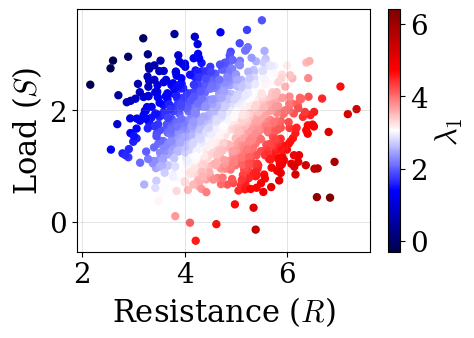

In [14]:
### Figure name and DPI
dpi = 600
name = 'lambda_1_t-0'

### Chart dimensions (in centimeters)
b_cm = 12
h_cm = 8
inches_to_cm = 1 / 2.54
b_input = b_cm * inches_to_cm
h_input = h_cm * inches_to_cm

### Axis and labels
label_x = 'Resistance ($R$)'
label_y = 'Load ($S$)'
label_cmap = r'$\lambda_{1}$'

size_label = 22
size_axis = 20

# 🔹 tamanhos específicos da colorbar
size_cbar_label = 22
size_cbar_ticks = 20

color_label = 'black'
color_axis = 'black'

### Scatter
cmap_type = 'seismic'
size_scatter = 25

### Grid
on_or_off = True
line_width_grid = 0.5
alpha_grid = 0.3
style_grid = '-'
color_grid = 'gray'

### Figure
fig, ax = plt.subplots(figsize=(b_input, h_input))

ax.tick_params(axis='both', which='major',
               labelsize=size_axis,
               colors=color_axis)

ax.set_xlabel(label_x, fontsize=size_label, color=color_label)
ax.set_ylabel(label_y, fontsize=size_label, color=color_label)

### Grid
ax.grid(on_or_off, which='both',
        linestyle=style_grid,
        linewidth=line_width_grid,
        color=color_grid,
        alpha=alpha_grid)

### Scatter plot
sc = ax.scatter(
    glam_data_0['r'],
    glam_data_0['s'],
    c=glam_data_0['lambda 1'],
    cmap=cmap_type,
    s=size_scatter
)

### Colorbar (AJUSTE PRINCIPAL)
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label(label_cmap,
               fontsize=size_cbar_label,
               color=color_label)

cbar.ax.tick_params(labelsize=size_cbar_ticks)

### Save
fig.savefig(f'z_{name}.png', dpi=dpi, bbox_inches='tight')
plt.show()


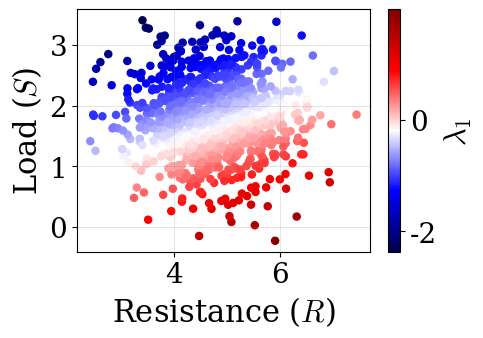

In [15]:
### Figure name and DPI
dpi = 600
name = 'lambda_1_t-50'

### Chart dimensions (in centimeters)
b_cm = 12
h_cm = 8
inches_to_cm = 1 / 2.54
b_input = b_cm * inches_to_cm
h_input = h_cm * inches_to_cm

### Axis and labels
label_x = 'Resistance ($R$)'
label_y = 'Load ($S$)'
label_cmap = r'$\lambda_{1}$'

size_label = 22
size_axis = 20

# 🔹 tamanhos específicos da colorbar (iguais ao t=0)
size_cbar_label = 22
size_cbar_ticks = 20

color_label = 'black'
color_axis = 'black'

### Scatter
cmap_type = 'seismic'
size_scatter = 26

### Grid
on_or_off = True
line_width_grid = 0.5
alpha_grid = 0.3
style_grid = '-'
color_grid = 'gray'

### Figure
fig, ax = plt.subplots(figsize=(b_input, h_input))

ax.tick_params(axis='both', which='major',
               labelsize=size_axis,
               colors=color_axis)

ax.set_xlabel(label_x, fontsize=size_label, color=color_label)
ax.set_ylabel(label_y, fontsize=size_label, color=color_label)

### Grid
ax.grid(on_or_off, which='both',
        linestyle=style_grid,
        linewidth=line_width_grid,
        color=color_grid,
        alpha=alpha_grid)

### Scatter plot
sc = ax.scatter(
    glam_data_50['r'],
    glam_data_50['s'],
    c=glam_data_50['lambda 1'],
    cmap=cmap_type,
    s=size_scatter
)

### Colorbar (AJUSTE PRINCIPAL)
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label(label_cmap,
               fontsize=size_cbar_label,
               color=color_label)

cbar.ax.tick_params(labelsize=size_cbar_ticks)

### Save
fig.savefig(f'z_{name}.png', dpi=dpi, bbox_inches='tight')
plt.show()
